In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

# Toujours afficher tous le contenu du Dataframe
pd.set_option('display.max_columns', None)

# Pré-requis : exécuter 1-analyse_exploratoire pour obtenir le fichier unifié et nettoyé
file_path = './assets/sirh_unifie.csv'
df = None

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
else:
    print(f"✗ Le fichier {file_path} n'existe pas")
    print("Assurez-vous d'avoir bien exécuté la partie 1-analyse_exploratoire")


# Préparer la modélisation
## Définition de la cible

Dans notre cas la variable cible pour comprendre l'attrition est claire, il s'agit de `a_quitte_l_entreprise`

## Préparation des données

### Normalisation des valeurs binaires


In [2]:
# Normalisation des champs booléens (True/False vers 1/0)
colonnes_bool = ['heure_supplementaires', 'a_quitte_l_entreprise']
for col in colonnes_bool:
    df[col] = df[col].apply(lambda x: 1 if x else 0)

# Conversion de la colonne "genre" en entiers
df['genre'] = df['genre'].apply(lambda x: 0 if x == 'M' else 1)  


### Normalisation des pourcentages

In [3]:
def normalize_average(x):
    return float(x.replace('%', '')) / 100
    
df['augementation_salaire_precedente'] = df['augementation_salaire_precedente'].apply(normalize_average) 

### Normalisation des notes d'évaluation

In [4]:
# Fonction de normalisation pour les notes (1-4 vers 0-1)
def normalize_note(x):
    return (x - 1) / (4 - 1)

# Colonnes de notes à normaliser
colonnes_notes = [
    'satisfaction_employee_environnement',
    'note_evaluation_precedente',
    'satisfaction_employee_nature_travail',
    'satisfaction_employee_equipe',
    'satisfaction_employee_equilibre_pro_perso',
    'note_evaluation_actuelle'
]

# Application de la normalisation
for col in colonnes_notes:
    df[col] = df[col].apply(normalize_note)

### Encodage des valeurs catégorielles

#### Catégories non ordinales
Pour les catégories qui ne représentent pas une notion d'ordre de classement (par exemple valeurs A > B > C, etc.), nous utilisons un `OneHotEncoder`


In [5]:
# Initialiser le OneHotEncoder avec drop='first' pour n-1 catégories
encoder = OneHotEncoder(drop='first', sparse_output=False, dtype=int)

# Colonnes catégorielles non ordinales
categories_non_ordinales = ['statut_marital', 'departement', 'poste', 'domaine_etude']

# Encoder la colonne statut_marital
encoded_data = encoder.fit_transform(df[categories_non_ordinales])

# Récupérer les noms des nouvelles colonnes
feature_names = encoder.get_feature_names_out(categories_non_ordinales)

# Créer un DataFrame avec les données encodées
df_encoded = pd.DataFrame(encoded_data, columns=feature_names, index=df.index)

# Supprimer les anciennes colonnes et ajouter les nouvelles
df = df.drop(categories_non_ordinales, axis=1)
df = pd.concat([df, df_encoded], axis=1)

# Vérification
print("Nouvelles colonnes créées :")
for name in feature_names:
    print(f"  - {name}")

print(f"\nNombre de nouvelles colonnes : {len(feature_names)}")
print(f"Type de données : {df_encoded.dtypes.iloc[0]}")

Nouvelles colonnes créées :
  - statut_marital_Divorcé(e)
  - statut_marital_Marié(e)
  - departement_Consulting
  - departement_Ressources Humaines
  - poste_Cadre Commercial
  - poste_Consultant
  - poste_Directeur Technique
  - poste_Manager
  - poste_Représentant Commercial
  - poste_Ressources Humaines
  - poste_Senior Manager
  - poste_Tech Lead
  - domaine_etude_Entrepreunariat
  - domaine_etude_Infra & Cloud
  - domaine_etude_Marketing
  - domaine_etude_Ressources Humaines
  - domaine_etude_Transformation Digitale

Nombre de nouvelles colonnes : 17
Type de données : int64


#### Catégories ordinales
On a une catégorie ordinale dans notre jeu de données : `frequence_deplacements`. Les valeurs sont croissantes.
On va transformer cette catégorie pour la rendre lisible pour nos modèles.

In [6]:
frequence_mapping = {
    'Aucun': 0,
    'Occasionnel': 1, 
    'Frequent': 2
}

# Appliquer l'encodage
df['frequence_deplacement_encoded'] = df['frequence_deplacement'].map(frequence_mapping)

# Vérifier le résultat
print("\nVérification de l'encodage:")
print(df[['frequence_deplacement', 'frequence_deplacement_encoded']].value_counts().sort_index())

df = df.drop(['frequence_deplacement'], axis=1)


Vérification de l'encodage:
frequence_deplacement  frequence_deplacement_encoded
Aucun                  0                                 150
Frequent               2                                 277
Occasionnel            1                                1043
Name: count, dtype: int64


## Analyse des corrélations

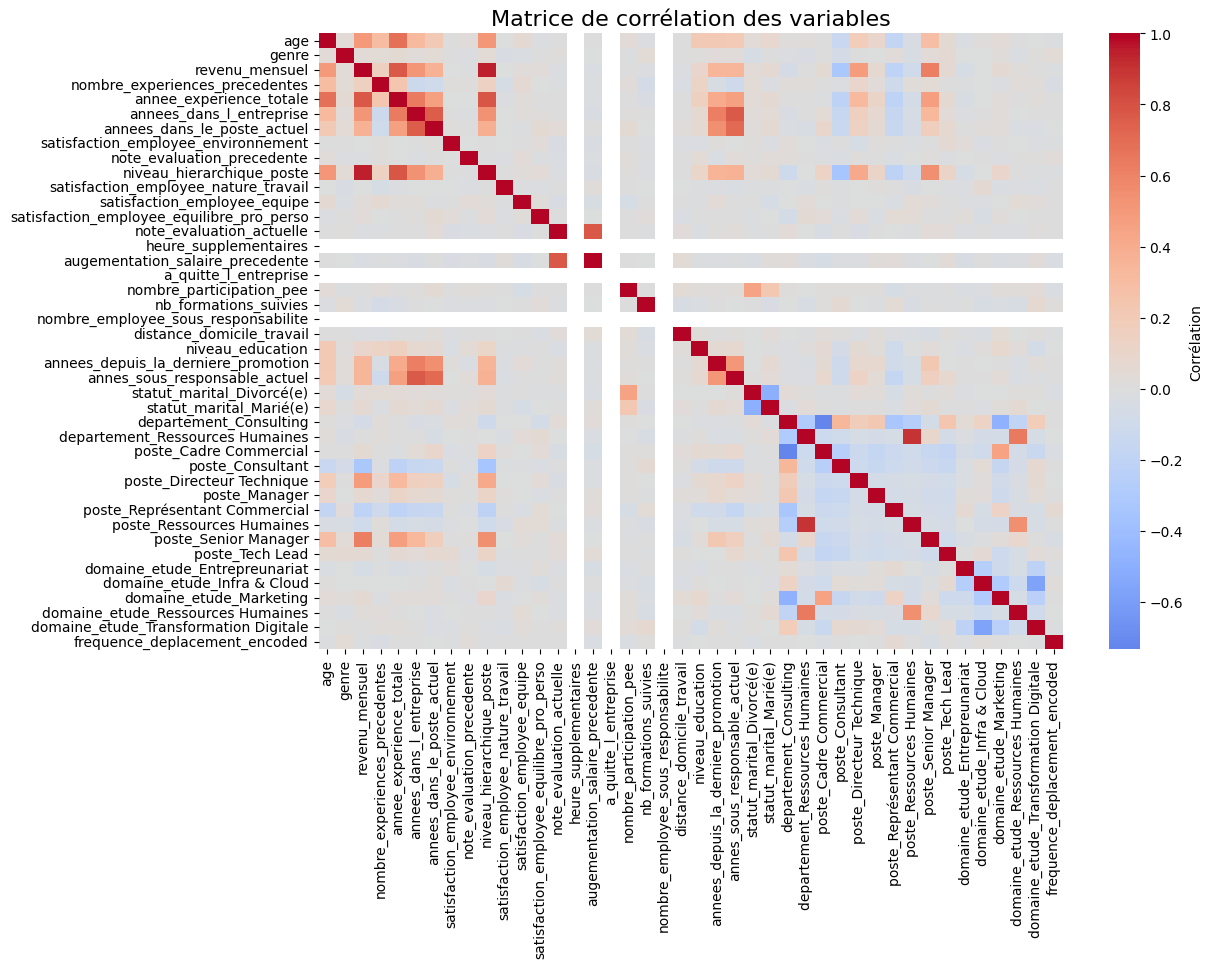

In [8]:
# Calcul de la matrice de corrélation
corr = df.corr(method='pearson')

# Taille de la figure
plt.figure(figsize=(12,8))

# Heatmap
sns.heatmap(
    corr,
    annot=False,         # affiche les coefficients dans les cases
    fmt=".2f",          # deux décimales
    cmap="coolwarm",    # couleurs rouge/bleu
    center=0,           # centre la palette à 0
    cbar_kws={'label': 'Corrélation'}
)

plt.title("Matrice de corrélation des variables", fontsize=16)
plt.show()